<a href="https://colab.research.google.com/github/Pamela1005/neural_network/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Core Training Concepts**

These terms define how your model learns from data.

**Epoch:** One complete pass through your entire training dataset. If you have 1,000 images and an epoch size of 1, means the model has seen all 1,000 images once.

**Batch Size:** Because loading a massive dataset into memory all at once is often impossible, we break it into smaller "batches." Batch size is the number of training examples used in one iteration to update the model's internal weights.

**Stratified (Sampling/Splitting):** This is a data preparation technique. When splitting your data into training and testing sets, "stratified" ensures that the distribution of your target classes remains the same in both the train and test sets.

**Example:** If your dataset is 80% "Cats" and 20% "Dogs," a stratified split ensures both your training and test sets maintain that 80/20 ratio. This is critical for imbalanced datasets.

**2. Activation Functions**

Activation functions add non-linearity to a neural network, allowing it to learn complex patterns rather than just simple linear relationships.

| Activation Function | Mathematical Formula | Primary Use Case |
| :--- | :--- | :--- |
| **ReLU** | $f(x) = \max(0, x)$ | Hidden layers; prevents vanishing gradient |
| **Sigmoid** | $f(x) = \frac{1}{1 + e^{-x}}$ | Binary classification (output layer) |
| **Softmax** | $f(x) = \frac{e^{x_i}}{\sum e^{x_j}}$ | Multi-class classification (output layer) |
| **Tanh** | $f(x) = \tanh(x)$ | Centering data between -1 and 1 |

**3. Handling Data: Structured vs. Unstructured**

The type of architecture you choose depends heavily on the structure of your data.

Structured Data (Tables, CSVs, Excel)
ANNs (Artificial Neural Networks/MLPs): These are best. Structured data (like age, salary, transaction amounts) has no inherent spatial relationship. ANNs treat each column as an independent feature.

Unstructured Data (Images, Audio, Text)
CNNs (Convolutional Neural Networks): These are specifically designed for data with spatial or temporal hierarchies (like images, where pixels near each other are related).

How: CNNs use filters (kernels) to slide over the image, "seeing" edges, textures, and eventually complex shapes.

Handling in ANNs: You can flatten an image into a long 1D array of pixels and feed it into an ANN, but it ignores spatial relationships, usually resulting in very poor performance.

**4. What is a "Layer"?**

A layer is a modular component of a neural network. It takes input data, performs a mathematical transformation (usually a weighted sum followed by an activation function), and passes the result to the next layer.ANN Layers (Fully Connected/Dense): Every neuron in this layer connects to every neuron in the previous layer. It calculates $Output = Activation(Weight \times Input + Bias)$.CNN Layers:Convolutional Layer: Learns local patterns (edges, shapes) by sliding filters over the image.Pooling Layer (e.g., Max Pooling): Reduces the spatial dimensions (downsampling) to make the model computationally efficient and less sensitive to exact location.

**5. Concepts Used in ANN and CNN**
Key Concepts in ANN
Weights and Biases: The "learnable" parameters. The network adjusts these during training to minimize error.

Backpropagation: The process of calculating the error (gradient) and sending it backward through the network to update weights.

Optimizer: The algorithm (e.g., Adam, SGD) that decides how to update the weights based on the calculated error.

Key Concepts in CNN
Kernel/Filter: A small matrix (e.g., 3x3) that slides over the image to extract features.

Stride: How many pixels the filter jumps as it slides over the image.

Padding: Adding extra pixels (usually zeros) around the border of an image so the filter can cover the edges effectively.

Flattening: Converting the final 2D feature maps from the convolutional layers into a 1D vector to feed into a standard ANN layer for final classification.


**ANN Preprocessing Workflow**

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# 1. LOAD YOUR DATASET
# Change 'your_dataset.csv' to your actual file name
df = pd.read_csv('/content/AI_Impact_Student_Life_2026.csv')

# 2. DEFINE YOUR TARGET
# Change 'target_column_name' to the name of the column you want to predict
target = 'Time_Saved_Hours_Weekly'
X = df.drop(target, axis=1)
y = df[target]

# 3. AUTOMATICALLY IDENTIFY COLUMN TYPES
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# 4. BUILD THE PREPROCESSING PIPELINE
# Numeric: Fills gaps with median, scales data (mean=0, std=1)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: Fills gaps with 'missing', converts text to binary columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 5. EXECUTE PREPROCESSING
X_processed = preprocessor.fit_transform(X)

# Handle Target (If target is text, encode it)
if y.dtype == 'object':
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y = le.fit_transform(y)

# 6. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# 7. BUILD THE ANN
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.2), # Prevents overfitting
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') # Use 'softmax' + 'categorical_crossentropy' if > 2 classes
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 8. TRAIN
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.0000e+00 - loss: -15.2130 - val_accuracy: 0.0000e+00 - val_loss: -53.5156
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: -159.3072 - val_accuracy: 0.0000e+00 - val_loss: -377.9104
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: -746.4460 - val_accuracy: 0.0000e+00 - val_loss: -1406.1985
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: -2250.7297 - val_accuracy: 0.0000e+00 - val_loss: -3670.0730
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0000e+00 - loss: -5152.7739 - val_accuracy: 0.0000e+00 - val_loss: -7683.5352
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.0000e+00 - loss: -9978.7891 - val_accuracy: 0.0000e+00 - val_loss: -13957.9326
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.0000e+00 - loss: -17130.1895 - val_accuracy: 0.0000e+00 - val_loss: -23010.3145
Epoch 

In [3]:
# 7. BUILD THE ANN (REVISED FOR REGRESSION)
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    # Use 1 unit with NO activation for regression (predicts a continuous number)
    Dense(1)
])

# Use Mean Squared Error (mse) for regression loss
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 8. TRAIN
# The loss should now decrease and stay positive
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 64.9777 - mae: 6.9275 - val_loss: 33.5750 - val_mae: 4.7988
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 19.0907 - mae: 3.6978 - val_loss: 18.7927 - val_mae: 3.7632
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 15.6124 - mae: 3.3983 - val_loss: 18.2647 - val_mae: 3.7203
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 14.0558 - mae: 3.2099 - val_loss: 18.9217 - val_mae: 3.7876
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 12.8190 - mae: 3.0350 - val_loss: 18.1717 - val_mae: 3.7108
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 11.2534 - mae: 2.8150 - val_loss: 18.4142 - val_mae: 3.7346
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 9.7685 - mae: 2.5787 - val_loss: 18.6027 - val_mae: 3.7577
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.0414 - mae: 2.3105 - val_loss: 18.4186 - val_mae: 3.7424
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step -

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


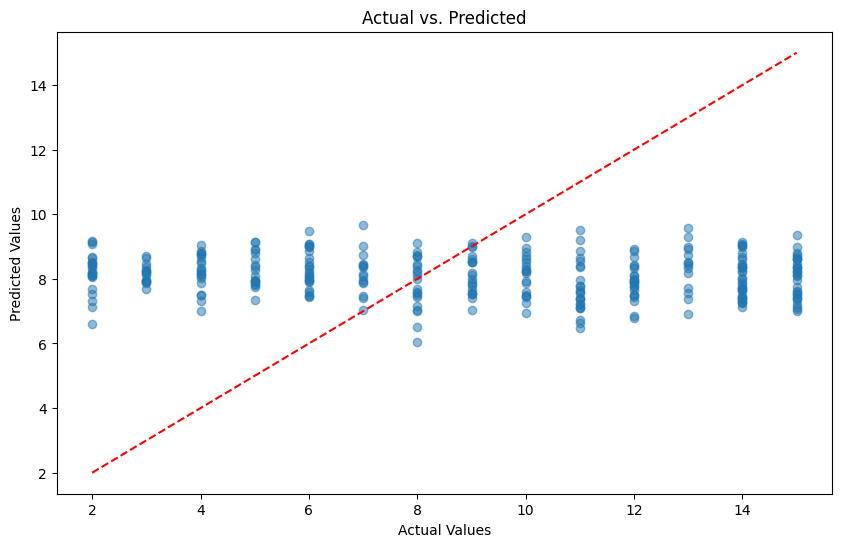

In [4]:
import matplotlib.pyplot as plt

# Generate predictions
y_pred = model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Perfect prediction line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted')
plt.show()

In [5]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the callback
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train again with the callback
history = model.fit(
    X_train, y_train,
    epochs=100, # Set a high number, it will stop automatically
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.5444 - mae: 0.5695 - val_loss: 19.0428 - val_mae: 3.8147
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.5011 - mae: 0.5439 - val_loss: 19.0460 - val_mae: 3.8082
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.5167 - mae: 0.5506 - val_loss: 19.0079 - val_mae: 3.8060
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4886 - mae: 0.5255 - val_loss: 18.9905 - val_mae: 3.8030
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4888 - mae: 0.5313 - val_loss: 18.5368 - val_mae: 3.7511
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4869 - mae: 0.5314 - val_loss: 18.9237 - val_mae: 3.8043
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5400 - mae: 0.5613 - val_loss: 18.9994 - val_mae: 3.7987
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4760 - mae: 0.5216 - val_loss: 18.9019 - val_mae: 3.8015
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

**CNNs (Convolutional Neural Networks)**

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout

# 1. LOAD DATA
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# 2. PREPROCESSING (Normalization: Scale pixels to 0-1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 3. BUILD CNN ARCHITECTURE
model = Sequential([
    Input(shape=(32, 32, 3)),

    # Feature Extraction
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),

    # Classification
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax') # 10 classes in CIFAR-10
])

# 4. COMPILE
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. TRAIN
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_test, y_test))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 55ms/step - accuracy: 0.4362 - loss: 1.5445 - val_accuracy: 0.5407 - val_loss: 1.2829
Epoch 2/10
 388/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 40ms/step - accuracy: 0.5524 - loss: 1.2488

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the labels for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Get predictions
predictions = model.predict(X_test[:5])

# Plot the first 5 test images and their predictions
plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i])
    actual_idx = np.argmax(y_test[i])
    pred_idx = np.argmax(predictions[i])
    plt.title(f"Act: {class_names[actual_idx]}\nPred: {class_names[pred_idx]}")
    plt.axis('off')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step


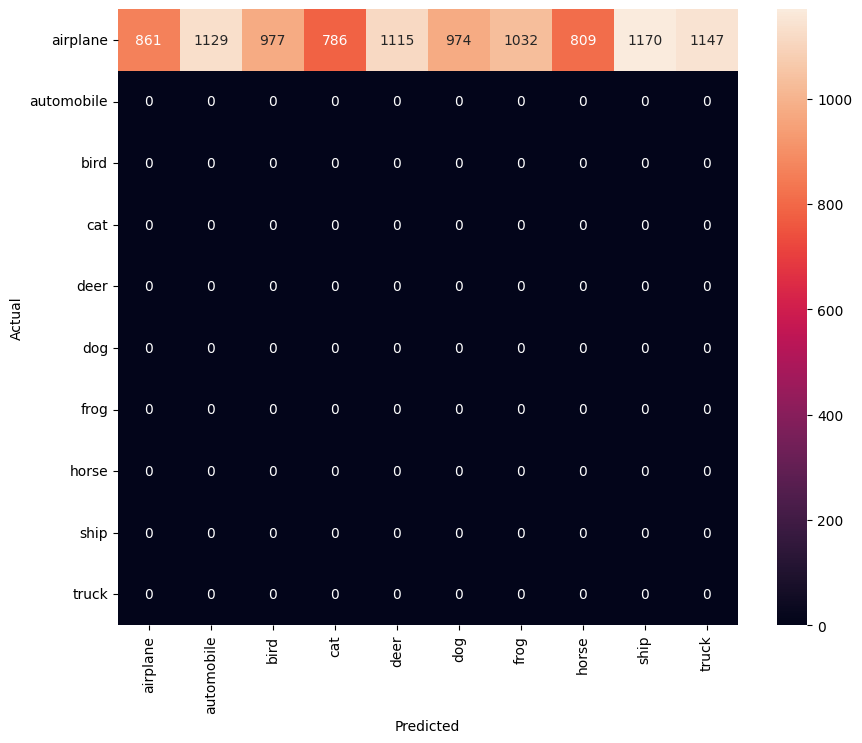

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

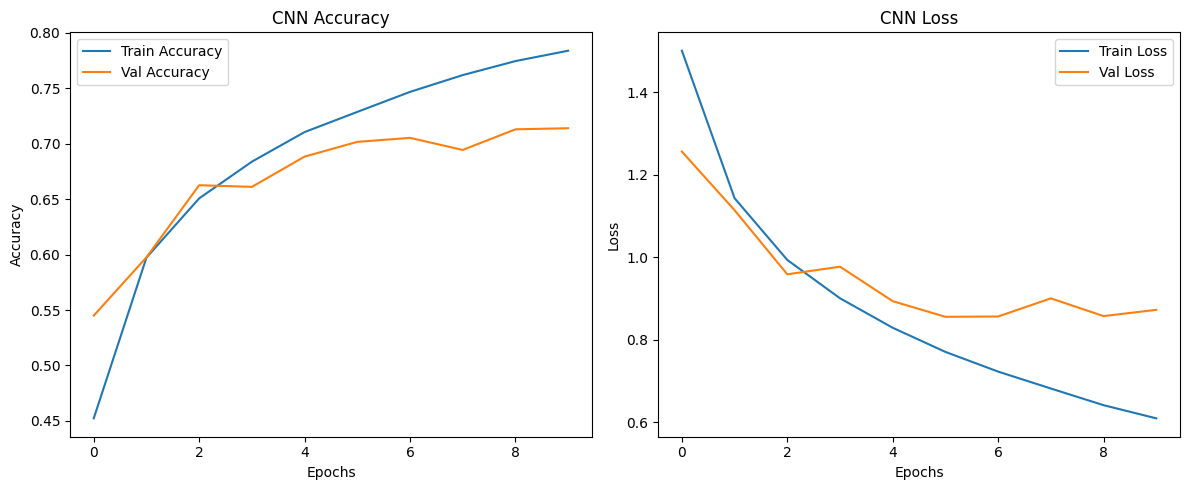


Final Test Accuracy: 71.40%


In [ ]:
import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Print Final Test Accuracy
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {acc*100:.2f}%")